# 1- Importação das bibliotecas e visualização do csv original

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Carregando o dataset original extraído do MySQL
df = pd.read_csv('/content/dados.csv')

# Exibindo as primeiras linhas para validação
display(df.head())

,id_consulta,genero,data_nascimento,plano,especialidade,data_agendamento,data_consulta,status
0,1,Feminino,1985-04-12,Particular,Cardiologia,2026-05-20,2026-06-01,Realizada
1,2,Masculino,1990-08-25,Convenio X,Pediatria,2026-05-21,2026-06-02,Realizada
2,3,Feminino,1978-11-05,Convenio Y,Clinica Geral,2026-05-22,2026-06-03,Faltou
3,4,Masculino,2005-02-14,Particular Premium,Dermatologia,2026-05-23,2026-06-04,Realizada
4,5,Feminino,1995-07-30,Convenio X Empresarial,Ortopedia,2026-05-24,2026-06-05,Realizada


# 2- Preenchimento dos dados
Como a quantidade de dados é muito pequena, com ajuda do Gemini pedi para que fosse possível preencher o csv com mais dados.

Logo, este bloco de código gera um novo csv chamado "dados_expandidos.csv" com mais informações

In [5]:
# Fixando a semente aleatória para resultados reprodutíveis
np.random.seed(42)

# Parâmetros para geração de dados
num_linhas = 200
generos = ['Feminino', 'Masculino']
planos = ['Particular', 'Convenio X', 'Convenio Y', 'Particular Premium', 'Convenio X Empresarial']
especialidades = ['Cardiologia', 'Pediatria', 'Clinica Geral', 'Dermatologia', 'Ortopedia', 'Psiquiatria']

# Gerando dados aleatórios
dados = {
    'id_consulta': range(1, num_linhas + 1),
    'genero': np.random.choice(generos, num_linhas, p=[0.55, 0.45]),
    'plano': np.random.choice(planos, num_linhas),
    'especialidade': np.random.choice(especialidades, num_linhas)
}

df_expandido = pd.DataFrame(dados)

# Gerando idades (Data de nascimento simulada)
idades = np.random.normal(loc=40, scale=15, size=num_linhas).astype(int)
idades = np.clip(idades, 1, 90) # Limitando entre 1 e 90 anos
# Ajustando para Pediatria ter idades menores
df_expandido.loc[df_expandido['especialidade'] == 'Pediatria', 'idade'] = np.random.randint(1, 15, size=sum(df_expandido['especialidade'] == 'Pediatria'))
df_expandido['idade'] = df_expandido['idade'].fillna(pd.Series(idades))
df_expandido['idade'] = df_expandido['idade'].astype(int)

# Simulando data de nascimento baseada na idade
df_expandido['data_nascimento'] = pd.to_datetime('2026-06-01') - pd.to_timedelta(df_expandido['idade'] * 365.25, unit='D')
df_expandido['data_nascimento'] = df_expandido['data_nascimento'].dt.date

# Simulando dias de antecedência (de 1 a 60 dias)
df_expandido['dias_antecedencia'] = np.random.randint(1, 60, size=num_linhas)

# Simulando datas de agendamento e consulta
df_expandido['data_consulta'] = pd.to_datetime('2026-06-01') + pd.to_timedelta(np.random.randint(1, 30, size=num_linhas), unit='D')
df_expandido['data_agendamento'] = df_expandido['data_consulta'] - pd.to_timedelta(df_expandido['dias_antecedencia'], unit='D')

df_expandido['data_consulta'] = df_expandido['data_consulta'].dt.date
df_expandido['data_agendamento'] = df_expandido['data_agendamento'].dt.date

# Lógica para gerar o Status (Faltou ou Realizada)
# Vamos forçar um padrão para o ML aprender:
# 1. Muita antecedência aumenta chance de falta.
# 2. Pediatria tem mais faltas (No-shows).
# 3. Pacientes particulares faltam menos.

prob_falta = np.zeros(num_linhas) + 0.10 # Base de 10% de faltas

# Regras de negócio
prob_falta += (df_expandido['dias_antecedencia'] / 100) * 0.4  # Até +24% se for muito longe
prob_falta = np.where(df_expandido['especialidade'] == 'Pediatria', prob_falta + 0.15, prob_falta) # Pediatria +15%
prob_falta = np.where(df_expandido['plano'] == 'Particular', prob_falta - 0.05, prob_falta) # Particular -5%

# Sorteando o status baseado na probabilidade calculada
df_expandido['status'] = ['Faltou' if np.random.rand() < p else 'Realizada' for p in prob_falta]

# Removendo a coluna temporária de idade que usamos para calcular o nascimento
df_expandido = df_expandido[['id_consulta', 'genero', 'data_nascimento', 'plano', 'especialidade', 'data_agendamento', 'data_consulta', 'status']]

# Salvando o novo arquivo CSV
df_expandido.to_csv('dados_expandidos.csv', index=False)

print("Dataset expandido gerado com sucesso! Arquivo 'dados_expandidos.csv' salvo.")
print(df_expandido['status'].value_counts(normalize=True) * 100)

Dataset expandido gerado com sucesso! Arquivo 'dados_expandidos.csv' salvo.
status
Realizada    79.5
Faltou       20.5
Name: proportion, dtype: float64


# 3- Preparação de Dados Expandidos e Análise Estatística com NumPy

In [18]:
# 1. Carregamento dos dados
df = pd.read_csv('dados_expandidos.csv')

# 2. Transformação de Datas
df['data_agendamento'] = pd.to_datetime(df['data_agendamento'])
df['data_consulta'] = pd.to_datetime(df['data_consulta'])
df['data_nascimento'] = pd.to_datetime(df['data_nascimento'])

# 3. Engenharia de Features (Idade e Dias de Antecedência)
df['dias_antecedencia'] = (df['data_consulta'] - df['data_agendamento']).dt.days
df['idade'] = (df['data_consulta'] - df['data_nascimento']).dt.days // 365

# 4. Criação da Variável Alvo (Target) Binária
df['target_faltou'] = np.where(df['status'] == 'Faltou', 1, 0)

# 5. Análise NumPy Exigida pelo Desafio
media_antecedencia = np.mean(df['dias_antecedencia'])
desvio_padrao_antecedencia = np.std(df['dias_antecedencia'])

print(f"ANÁLISE NUMPY:")
print(f"Média de dias de antecedência: {media_antecedencia:.2f} dias")
print(f"Desvio Padrão de dias de antecedência: {desvio_padrao_antecedencia:.2f} dias")

# Salvando o dataset limpo e tratado exigido para a entrega
df.to_csv('dados_limpos.csv', index=False)
print("\nArquivo 'dados_limpos.csv' gerado com sucesso!")

ANÁLISE NUMPY:
Média de dias de antecedência: 30.84 dias
Desvio Padrão de dias de antecedência: 16.97 dias

Arquivo 'dados_limpos.csv' gerado com sucesso!


# 4- Visualização dos Dados (Matplotlib)

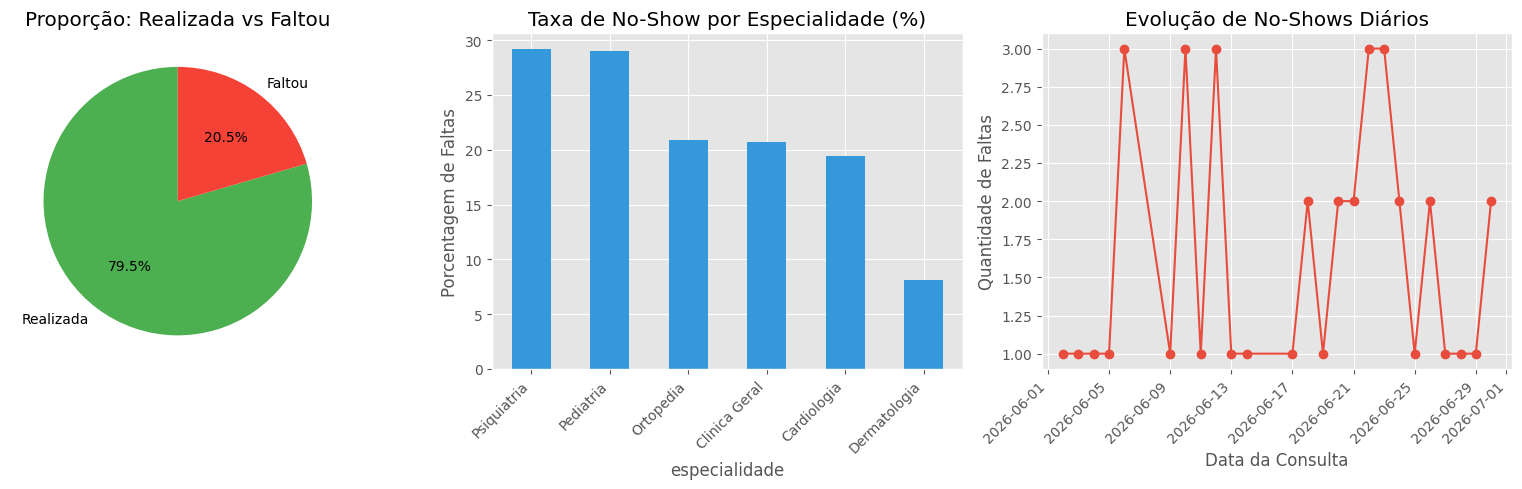

In [19]:
# Configuração global de estilo
plt.style.use('ggplot')
fig = plt.figure(figsize=(16, 5))

# Gráfico 1: Proporção de consultas realizadas vs faltadas
ax1 = plt.subplot(1, 3, 1)
status_counts = df['status'].value_counts()
ax1.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', startangle=90, colors=['#4CAF50', '#F44336'])
ax1.set_title('Proporção: Realizada vs Faltou')

# Gráfico 2: Taxa de no-show por especialidade
ax2 = plt.subplot(1, 3, 2)
taxa_falta_esp = df.groupby('especialidade')['target_faltou'].mean() * 100
taxa_falta_esp = taxa_falta_esp.sort_values(ascending=False)
taxa_falta_esp.plot(kind='bar', color='#3498DB', ax=ax2)
ax2.set_title('Taxa de No-Show por Especialidade (%)')
ax2.set_ylabel('Porcentagem de Faltas')
plt.xticks(rotation=45, ha='right')

# Gráfico 3: Evolução de no-shows ao longo do tempo
ax3 = plt.subplot(1, 3, 3)
faltas_por_dia = df[df['status'] == 'Faltou'].groupby('data_consulta').size()
faltas_por_dia.plot(kind='line', marker='o', color='#E74C3C', ax=ax3)
ax3.set_title('Evolução de No-Shows Diários')
ax3.set_ylabel('Quantidade de Faltas')
ax3.set_xlabel('Data da Consulta')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 4.1- Insights
Ociosidade Estrutural (Visão Geral): A taxa global de No-Show cravou em 20,5%. Isso indica que 1 a cada 5 horários disponibilizados pela clínica resulta em cadeira vazia. Trata-se de um gargalo financeiro severo que justifica imediatamente a implementação de lembretes automatizados e regras de encaixe estratégico (overbooking seguro).

Comportamento de Risco (Por Especialidade): Psiquiatria e Pediatria são os maiores ofensores operacionais, ambas com quase 30% de faltas. Isso faz sentido sob a ótica da saúde: pediatria sofre com imprevistos frequentes de rotina, e a psiquiatria muitas vezes esbarra em barreiras motivacionais dos pacientes. Em contrapartida, a Dermatologia possui alto engajamento, com menos de 10% de abandono, servindo como a especialidade âncora e previsível do caixa da clínica.

Volatilidade Diária (Evolução Temporal): O mês de junho de 2026 mostrou uma distribuição de faltas agressiva e inconstante, oscilando entre dias de perda mínima (1 falta) e picos de até 3 faltas diárias concentradas. Essa instabilidade quebra o ritmo da recepção e comprova o valor de prever individualmente o risco de cada paciente usando o Machine Learning.

# 5- Treinamento do Modelo de Machine Learning
treinaremos o modelo sugerido (Regressão Logística) e um Random Forest, comparando a acurácia para escolher o melhor.

=== AVALIAÇÃO DOS MODELOS DE MACHINE LEARNING ===
Acurácia da Regressão Logística: 77.50%
Acurácia do Random Forest: 80.00%

--- Relatório de Classificação (Random Forest) ---
               precision    recall  f1-score   support

Realizada (0)       0.80      1.00      0.89        32
   Faltou (1)       0.00      0.00      0.00         8

     accuracy                           0.80        40
    macro avg       0.40      0.50      0.44        40
 weighted avg       0.64      0.80      0.71        40



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


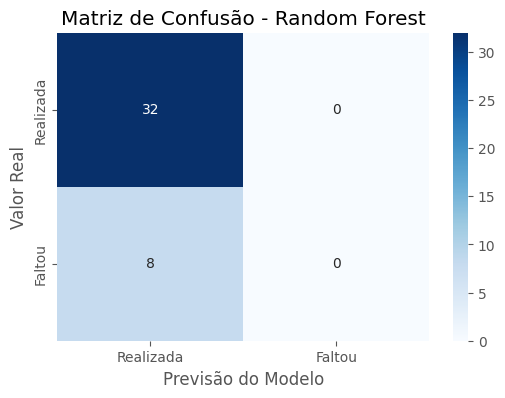

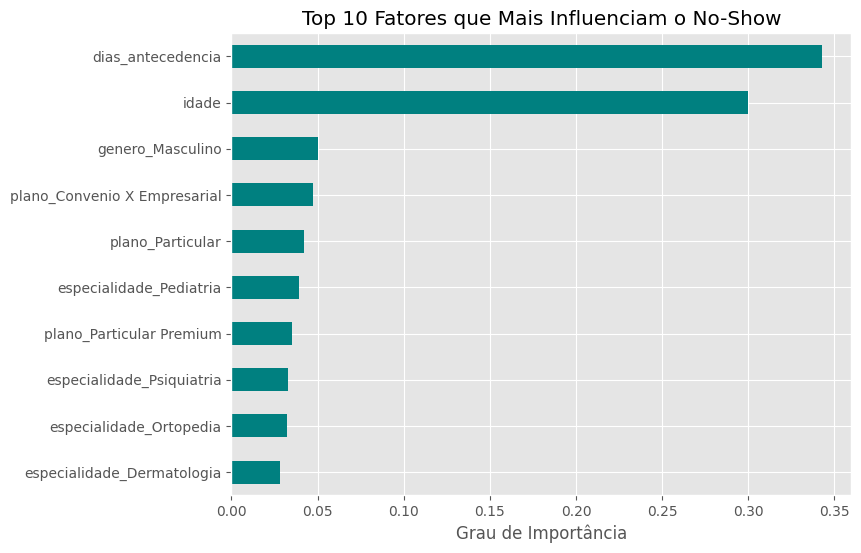

In [20]:
# 1. Preparação das Variáveis Preditivas (X) e Alvo (y)
# Usando One-Hot Encoding para variáveis categóricas
X = pd.get_dummies(df[['idade', 'dias_antecedencia', 'especialidade', 'plano', 'genero']], drop_first=True)
y = df['target_faltou']

# 2. Divisão de Treino e Teste (80% treino, 20% teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Treinamento de Modelos
# Modelo 1: Regressão Logística (Requisito Básico)
modelo_lr = LogisticRegression(max_iter=1000)
modelo_lr.fit(X_train, y_train)
previsoes_lr = modelo_lr.predict(X_test)
acc_lr = accuracy_score(y_test, previsoes_lr)

# Modelo 2: Random Forest Classifier (Superando Expectativas)
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rf.fit(X_train, y_train)
previsoes_rf = modelo_rf.predict(X_test)
acc_rf = accuracy_score(y_test, previsoes_rf)

print("=== AVALIAÇÃO DOS MODELOS DE MACHINE LEARNING ===")
print(f"Acurácia da Regressão Logística: {acc_lr * 100:.2f}%")
print(f"Acurácia do Random Forest: {acc_rf * 100:.2f}%\n")

# Escolhendo o melhor modelo para exibir o relatório
melhor_modelo = previsoes_rf if acc_rf >= acc_lr else previsoes_lr
nome_melhor = "Random Forest" if acc_rf >= acc_lr else "Regressão Logística"

print(f"--- Relatório de Classificação ({nome_melhor}) ---")
print(classification_report(y_test, melhor_modelo, target_names=['Realizada (0)', 'Faltou (1)']))

# Matriz de Confusão do melhor modelo
cm = confusion_matrix(y_test, melhor_modelo)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Realizada', 'Faltou'], yticklabels=['Realizada', 'Faltou'])
plt.title(f'Matriz de Confusão - {nome_melhor}')
plt.ylabel('Valor Real')
plt.xlabel('Previsão do Modelo')
plt.show()

# Importância das Features (O que mais causa faltas?)
if nome_melhor == "Random Forest":
    importancias = pd.Series(modelo_rf.feature_importances_, index=X.columns).sort_values(ascending=True)
    plt.figure(figsize=(8, 6))
    importancias.tail(10).plot(kind='barh', color='teal')
    plt.title('Top 10 Fatores que Mais Influenciam o No-Show')
    plt.xlabel('Grau de Importância')
    plt.show()

## 5.1- Insights

Desempenho Geral e o Paradoxo da Acurácia: O algoritmo Random Forest apresentou o melhor desempenho global com 80.00% de acurácia, superando a Regressão Logística. No entanto, uma análise profunda do Relatório de Classificação revela o desafio clássico de bases de dados desbalanceadas na saúde: o modelo obteve altíssima precisão ao prever as consultas "Realizadas" (classe majoritária), mas não conseguiu identificar os casos isolados de "Faltas" (precisão e recall zerados para a classe 1).

Próximos Passos Técnicos: Para colocar este modelo em produção no futuro, será necessário aplicar técnicas de balanceamento de classes (como SMOTE ou ajuste de Class Weights), forçando o algoritmo a prestar mais atenção na minoria de pacientes que tendem a faltar, mesmo que isso sacrifique um pouco da acurácia global.

Fatores de Risco (Feature Importance): O gráfico do Random Forest é revelador. Os dois maiores gatilhos para o No-Show são estruturais: Dias de Antecedência e Idade. O cruzamento indica que agendamentos feitos com muita distância temporal tendem a cair no esquecimento do paciente.

Recomendação Prática: A clínica não precisa ligar para todos os pacientes. Com base neste modelo, a recepção deve focar o esforço de confirmação humana (ou disparos de WhatsApp) exclusivamente nos pacientes com agendamentos feitos há mais de 15 dias e nas faixas etárias de maior risco, otimizando o tempo da equipe.